# NSGD Autoscaling — Experiment Analysis

Reads experiment CSVs from the NSGD middleware and produces graphs for:
- Paper figures (θ convergence, cost comparison)
- Cross-metric comparison: NSGD cost (eq. 7) vs LSTM-PPO reward (env.py)

**Files expected:**
- `logs/nsgd/request_log.csv` — per-request data
- `logs/nsgd/samples.csv` — periodic aggregates (every 30s)
- *(optional)* `reward_history_PPO_LSTM_Run3_cpu.json` — LSTM-PPO results

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
import os

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
})

LOG_DIR = 'logs/nsgd_constant_poss_5'
PPO_REWARD_FILE = 'reward_history_PPO_LSTM_Run3_cpu.json'

requests = pd.read_csv(f'{LOG_DIR}/request_log.csv')
samples = pd.read_csv(f'{LOG_DIR}/samples.csv')

requests['datetime'] = pd.to_datetime(requests['timestamp'], unit='s')
samples['datetime'] = pd.to_datetime(samples['timestamp'], unit='s')

training = requests[requests['mode'] == 'training'].copy()
evaluation = requests[requests['mode'] == 'evaluation'].copy()

print(f'Request log:  {len(requests):,} rows')
print(f'  Training:   {len(training):,}')
print(f'  Evaluation: {len(evaluation):,}')
print(f'Samples:      {len(samples):,} rows')
print(f'Duration:     {(requests.timestamp.max() - requests.timestamp.min()) / 60:.1f} minutes')
print()
print('Columns in samples.csv:')
print(' ', [c for c in samples.columns if 'lstm' in c or 'reward' in c or 'nsgd' in c])

Request log:  19,127 rows
  Training:   19,127
  Evaluation: 0
Samples:      128 rows
Duration:     63.7 minutes

Columns in samples.csv:
  ['nsgd_cost', 'lstm_ppo_reward', 'reward_throughput', 'reward_cpu', 'reward_mem', 'reward_replicas']


---
## Figure 2 — θ Convergence Over Iterations

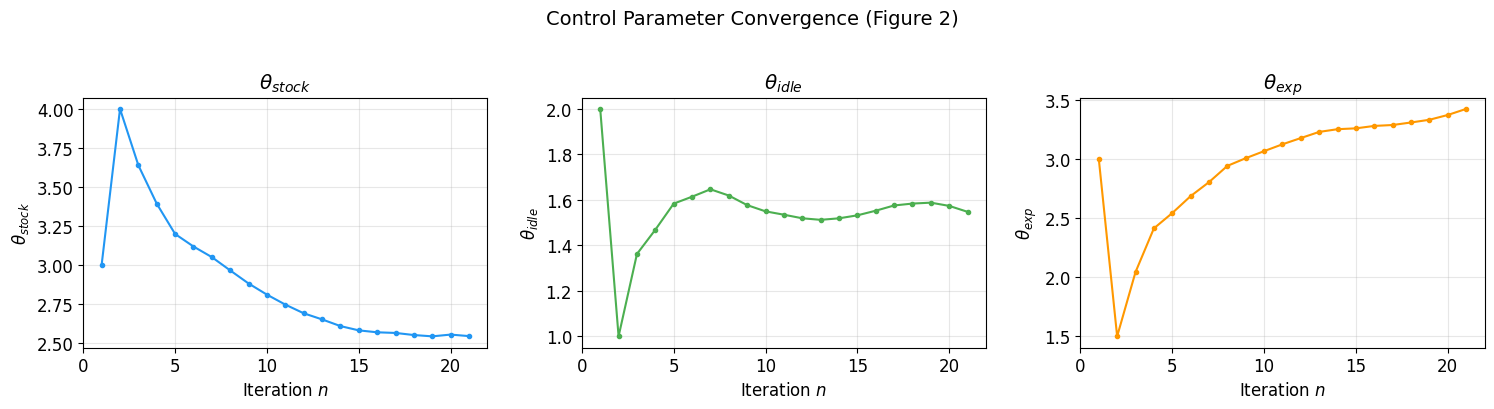

In [29]:
convergence = (
    training
    .dropna(subset=['iteration', 'theta_base_stock'])
    .groupby('iteration')
    .first()
    [['theta_base_stock', 'theta_base_idle', 'theta_base_exp']]
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['theta_base_stock', 'theta_base_idle', 'theta_base_exp'],
    [r'$\theta_{stock}$', r'$\theta_{idle}$', r'$\theta_{exp}$'],
    ['#2196F3', '#4CAF50', '#FF9800'],
):
    ax.plot(convergence['iteration'], convergence[col], color=color, marker='o', markersize=3)
    ax.set_xlabel('Iteration $n$')
    ax.set_ylabel(label)
    ax.set_title(label)

fig.suptitle('Control Parameter Convergence (Figure 2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/fig2_theta_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## NSGD Cost Over Time (Training)

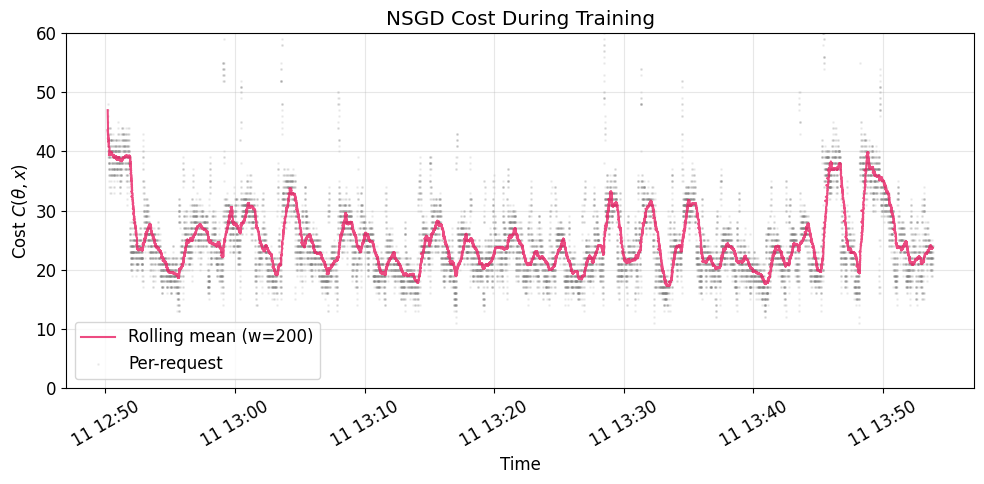

In [32]:
window = min(200, len(training) // 5) if len(training) > 10 else 1

fig, ax = plt.subplots()
ax.plot(
    training['datetime'],
    training['nsgd_cost'].rolling(window=window, min_periods=1).mean(),
    color='#E91E63', alpha=0.8, label=f'Rolling mean (w={window})'
)
ax.scatter(
    training['datetime'], training['nsgd_cost'],
    s=1, alpha=0.1, color='gray', label='Per-request'
)
ax.set_xlabel('Time')
ax.set_ylabel('Cost $C(\\theta, x)$')
ax.set_title('NSGD Cost During Training')

# Set the y-axis limits to exactly 0 and 60
ax.set_ylim(0, 60) 

ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/training_cost_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Cost Per Iteration (Averaged)

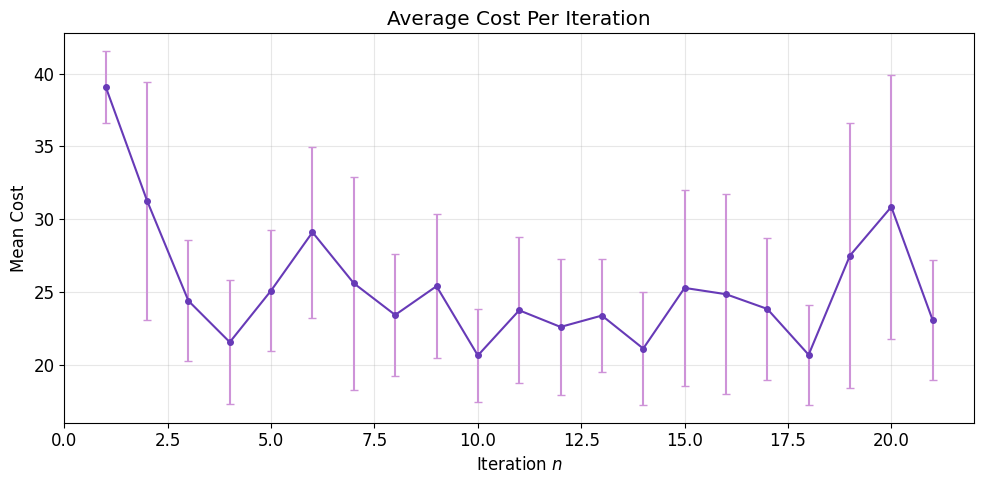

In [33]:
cost_per_iter = (
    training
    .dropna(subset=['iteration'])
    .groupby('iteration')['nsgd_cost']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

fig, ax = plt.subplots()
ax.errorbar(
    cost_per_iter['iteration'], cost_per_iter['mean'],
    yerr=cost_per_iter['std'], fmt='-o', markersize=4,
    capsize=3, color='#673AB7', ecolor='#CE93D8',
)
ax.set_xlabel('Iteration $n$')
ax.set_ylabel('Mean Cost')
ax.set_title('Average Cost Per Iteration')
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/cost_per_iteration.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation Cost Distribution
Cost under the learned fixed policy — the number reported in Figures 3/4.

In [19]:
if len(evaluation) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(evaluation['nsgd_cost'], bins=50, color='#009688', edgecolor='white')
    axes[0].axvline(evaluation['nsgd_cost'].mean(), color='red', linestyle='--',
                    label=f'Mean = {evaluation["nsgd_cost"].mean():.2f}')
    axes[0].set_xlabel('Cost $C(\\theta, x)$')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Evaluation Cost Distribution')
    axes[0].legend()

    axes[1].plot(evaluation['datetime'], evaluation['nsgd_cost'].rolling(50, min_periods=1).mean(),
                color='#009688')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Cost (rolling mean)')
    axes[1].set_title('Evaluation Cost Over Time')
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig(f'{LOG_DIR}/evaluation_cost.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Evaluation cost: mean={evaluation["nsgd_cost"].mean():.2f}, '
          f'std={evaluation["nsgd_cost"].std():.2f}, n={len(evaluation)}')
else:
    print('No evaluation data. Run: curl -X POST http://localhost:8000/mode/evaluate')

No evaluation data. Run: curl -X POST http://localhost:8000/mode/evaluate


---
## LSTM-PPO Reward — Computed on NSGD System State
The same reward function from `env.py`, evaluated on what NSGD produced.
Higher is better (opposite of NSGD cost where lower is better).

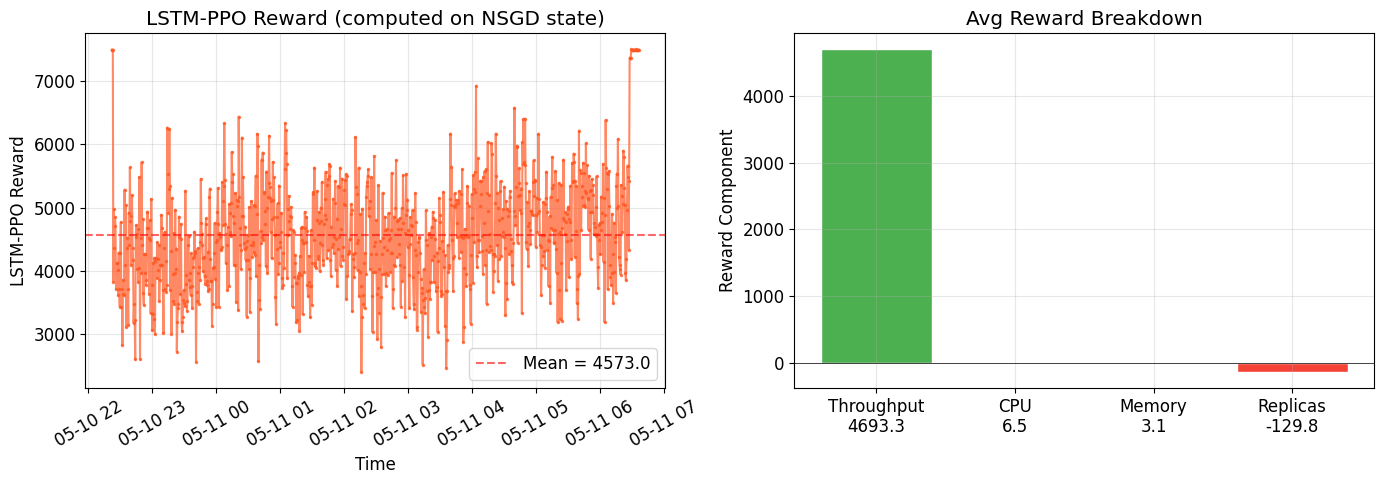

LSTM-PPO reward on NSGD system: mean=4572.97, std=852.63


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward over time
axes[0].plot(samples['datetime'], samples['lstm_ppo_reward'],
             color='#FF5722', marker='.', markersize=3, alpha=0.7)
axes[0].axhline(samples['lstm_ppo_reward'].mean(), color='red', linestyle='--', alpha=0.6,
                label=f'Mean = {samples["lstm_ppo_reward"].mean():.1f}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('LSTM-PPO Reward')
axes[0].set_title('LSTM-PPO Reward (computed on NSGD state)')
axes[0].legend()
plt.sca(axes[0])
plt.xticks(rotation=30)

# Reward component breakdown
components = samples[['reward_throughput', 'reward_cpu', 'reward_mem', 'reward_replicas']].mean()
colors = ['#4CAF50', '#2196F3', '#9C27B0', '#F44336']
labels = [f'Throughput\n{components["reward_throughput"]:.1f}',
          f'CPU\n{components["reward_cpu"]:.1f}',
          f'Memory\n{components["reward_mem"]:.1f}',
          f'Replicas\n{components["reward_replicas"]:.1f}']
vals = components.values
bar_colors = [c if v >= 0 else '#F44336' for v, c in zip(vals, colors)]
axes[1].bar(labels, vals, color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Reward Component')
axes[1].set_title('Avg Reward Breakdown')

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/lstm_ppo_reward.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'LSTM-PPO reward on NSGD system: mean={samples["lstm_ppo_reward"].mean():.2f}, '
      f'std={samples["lstm_ppo_reward"].std():.2f}')

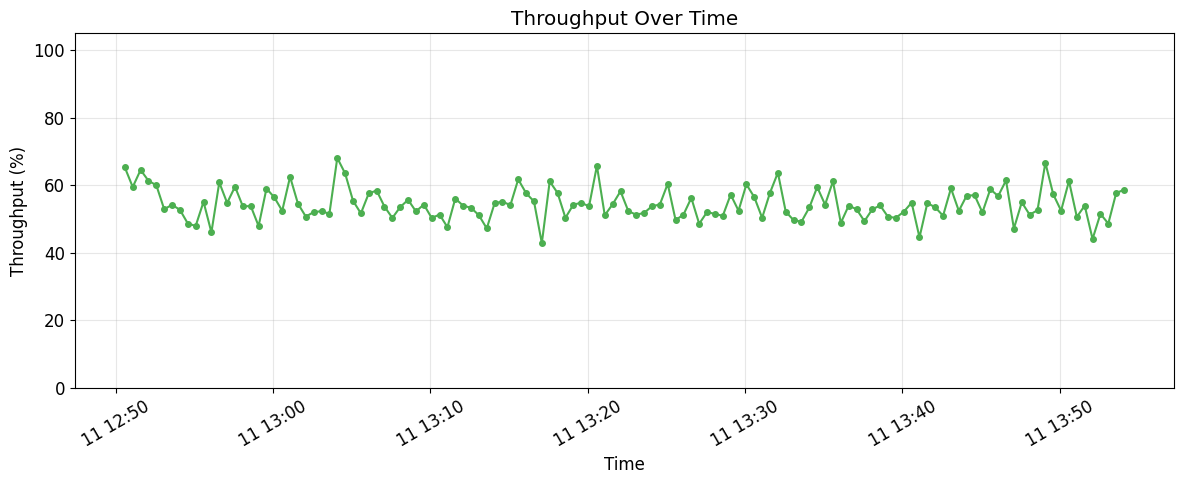

Mean throughput: 54.44%
Min:  42.86%
Max:  68.09%


In [34]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(samples['datetime'], samples['throughput'],
        color='#4CAF50', marker='o', markersize=4)
ax.set_xlabel('Time')
ax.set_ylabel('Throughput (%)')
ax.set_title('Throughput Over Time')
ax.set_ylim(0, 105)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/throughput_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean throughput: {samples["throughput"].mean():.2f}%')
print(f'Min:  {samples["throughput"].min():.2f}%')
print(f'Max:  {samples["throughput"].max():.2f}%')

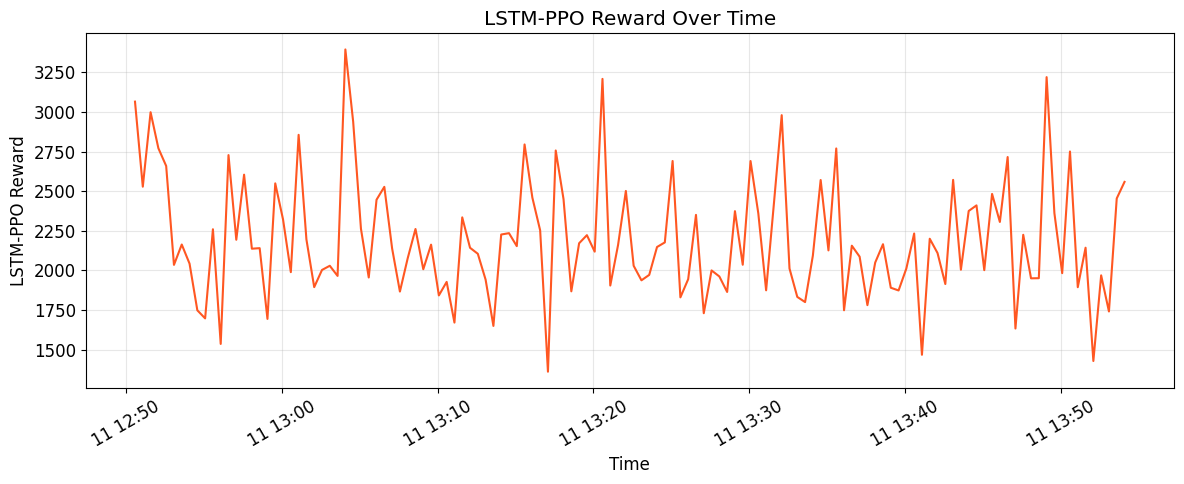

Mean reward: 2193.48
Min:  1361.11
Max:  3395.38


In [35]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(samples['datetime'], samples['lstm_ppo_reward'],
        color='#FF5722')
ax.set_xlabel('Time')
ax.set_ylabel('LSTM-PPO Reward')
ax.set_title('LSTM-PPO Reward Over Time')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/reward_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean reward: {samples["lstm_ppo_reward"].mean():.2f}')
print(f'Min:  {samples["lstm_ppo_reward"].min():.2f}')
print(f'Max:  {samples["lstm_ppo_reward"].max():.2f}')

In [25]:
# In Jupyter
samples['lambda_over_N_actual'] = (
    (samples['requests'] / 30) *
    samples['avg_execution_time'] / 24
)
print(samples[['datetime', 'requests', 'avg_execution_time', 'replicas', 'lambda_over_N_actual']].tail(10))

                        datetime  requests  avg_execution_time  replicas  \
64 2026-05-11 13:22:35.066549540       130               2.265        12   
65 2026-05-11 13:23:05.081794500       156               2.328        14   
66 2026-05-11 13:23:35.098196507       166               2.386        15   
67 2026-05-11 13:24:05.113481283       145               2.291        12   
68 2026-05-11 13:24:35.126182794       140               2.333        14   
69 2026-05-11 13:25:05.140129089       144               2.381        16   
70 2026-05-11 13:25:35.156302452       163               2.211        12   
71 2026-05-11 13:26:05.169867277       156               2.332        13   
72 2026-05-11 13:26:35.186709166       128               2.278        12   
73 2026-05-11 13:27:05.202599764       142               2.334        15   

    lambda_over_N_actual  
64              0.408958  
65              0.504400  
66              0.550106  
67              0.461382  
68              0.453639  
6

In [26]:
# Look at θ_base over the last 20 iterations
last_iters = (
    training
    .dropna(subset=['iteration', 'theta_base_stock'])
    .groupby('iteration')
    .first()
    .tail(9)
)

print("θ stability over last 20 iterations:")
for col in ['theta_base_stock', 'theta_base_idle', 'theta_base_exp']:
    mean = last_iters[col].mean()
    std = last_iters[col].std()
    cv = std / mean if mean != 0 else float('inf')
    print(f"  {col}: mean={mean:.3f}, std={std:.3f}, CV={cv:.3f}")

θ stability over last 20 iterations:
  theta_base_stock: mean=2.775, std=0.163, CV=0.059
  theta_base_idle: mean=1.557, std=0.048, CV=0.031
  theta_base_exp: mean=3.094, std=0.156, CV=0.050


## Dual-Axis: NSGD Cost vs LSTM-PPO Reward Over Time
Both metrics on the same timeline. NSGD wants cost DOWN, PPO wants reward UP.

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Time')
ax1.set_ylabel('NSGD Cost (lower = better)', color='#E91E63')
ax1.plot(samples['datetime'], samples['nsgd_cost'], color='#E91E63',
         alpha=0.7, marker='.', markersize=3, label='NSGD Cost')
ax1.tick_params(axis='y', labelcolor='#E91E63')

ax2 = ax1.twinx()
ax2.set_ylabel('LSTM-PPO Reward (higher = better)', color='#2196F3')
ax2.plot(samples['datetime'], samples['lstm_ppo_reward'], color='#2196F3',
         alpha=0.7, marker='.', markersize=3, label='PPO Reward')
ax2.tick_params(axis='y', labelcolor='#2196F3')

fig.suptitle('NSGD Cost vs LSTM-PPO Reward (Same System)', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/nsgd_vs_ppo_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparison with LSTM-PPO Training History
If you have the PPO reward history JSON file, this plots both agents' reward curves.

In [15]:
if os.path.exists(PPO_REWARD_FILE):
    with open(PPO_REWARD_FILE) as f:
        ppo_data = json.load(f)

    ppo_rewards = ppo_data['reward_history']
    ppo_episodes = list(range(1, len(ppo_rewards) + 1))

    # NSGD reward per sampling window (same unit as PPO episode)
    nsgd_rewards = samples['lstm_ppo_reward'].tolist()
    nsgd_episodes = list(range(1, len(nsgd_rewards) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Episodic reward comparison
    axes[0].plot(ppo_episodes, ppo_rewards, color='#FF5722', alpha=0.5, label='LSTM-PPO')
    axes[0].plot(nsgd_episodes, nsgd_rewards, color='#2196F3', alpha=0.5, label='NSGD')
    axes[0].set_xlabel('Episode / Sample')
    axes[0].set_ylabel('Reward (env.py formula)')
    axes[0].set_title('Per-Episode Reward')
    axes[0].legend()

    # Rolling mean comparison
    w = 20
    axes[1].plot(ppo_episodes,
                 pd.Series(ppo_rewards).rolling(w, min_periods=1).mean(),
                 color='#FF5722', label=f'LSTM-PPO (rolling {w})')
    axes[1].plot(nsgd_episodes,
                 pd.Series(nsgd_rewards).rolling(w, min_periods=1).mean(),
                 color='#2196F3', label=f'NSGD (rolling {w})')
    axes[1].set_xlabel('Episode / Sample')
    axes[1].set_ylabel('Reward (rolling mean)')
    axes[1].set_title('Smoothed Reward Comparison')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{LOG_DIR}/nsgd_vs_ppo_reward.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'LSTM-PPO: mean reward = {np.mean(ppo_rewards):.2f} (last 100: {np.mean(ppo_rewards[-100:]):.2f})')
    print(f'NSGD:     mean reward = {np.mean(nsgd_rewards):.2f} (last 100: {np.mean(nsgd_rewards[-100:]):.2f})')
else:
    print(f'{PPO_REWARD_FILE} not found. Run LSTM-PPO experiment to generate it.')
    print('Skipping direct comparison.')

reward_history_PPO_LSTM_Run3_cpu.json not found. Run LSTM-PPO experiment to generate it.
Skipping direct comparison.


---
## Replica Count Over Time

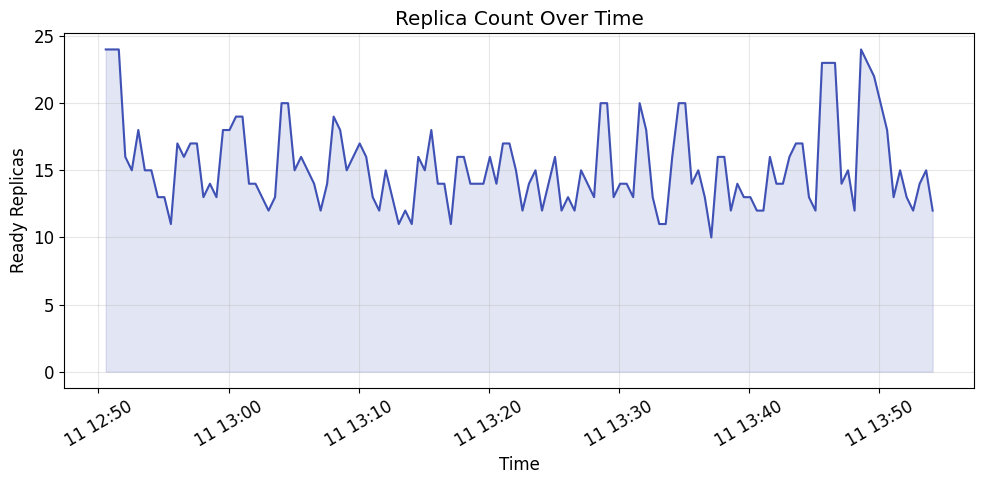

In [36]:
fig, ax = plt.subplots()

ax.plot(samples['datetime'], samples['replicas'], color='#3F51B5',)
ax.fill_between(samples['datetime'], 0, samples['replicas'], alpha=0.15, color='#3F51B5')
ax.set_xlabel('Time')
ax.set_ylabel('Ready Replicas')
ax.set_title('Replica Count Over Time')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/replicas_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Cold Start and Rejection Rates

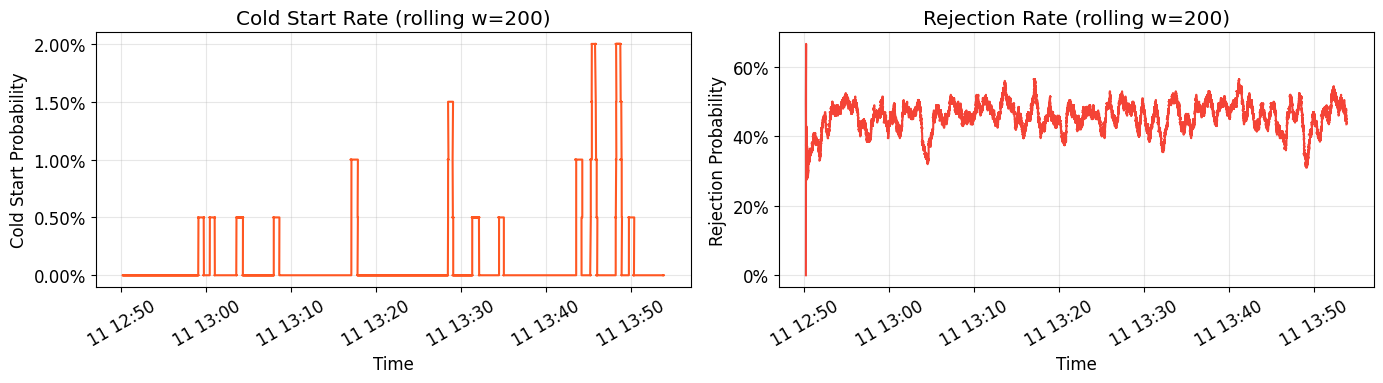

Cold start rate: 0.0012 (22 / 19127)
Rejection rate:  0.4585 (8770 / 19127)


In [37]:
data = requests.copy()
window = min(200, len(data) // 5) if len(data) > 10 else 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cold_start_roll = data['is_cold_start'].astype(float).rolling(window, min_periods=1).mean()
axes[0].plot(data['datetime'], cold_start_roll, color='#FF5722')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cold Start Probability')
axes[0].set_title(f'Cold Start Rate (rolling w={window})')
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

rejection_roll = data['rejected'].astype(float).rolling(window, min_periods=1).mean()
axes[1].plot(data['datetime'], rejection_roll, color='#F44336')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Rejection Probability')
axes[1].set_title(f'Rejection Rate (rolling w={window})')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

for ax in axes:
    plt.sca(ax)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/cold_start_rejection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Cold start rate: {data["is_cold_start"].mean():.4f} ({data["is_cold_start"].sum()} / {len(data)})')
print(f'Rejection rate:  {data["rejected"].mean():.4f} ({data["rejected"].sum()} / {len(data)})')

## Response Latency Distribution

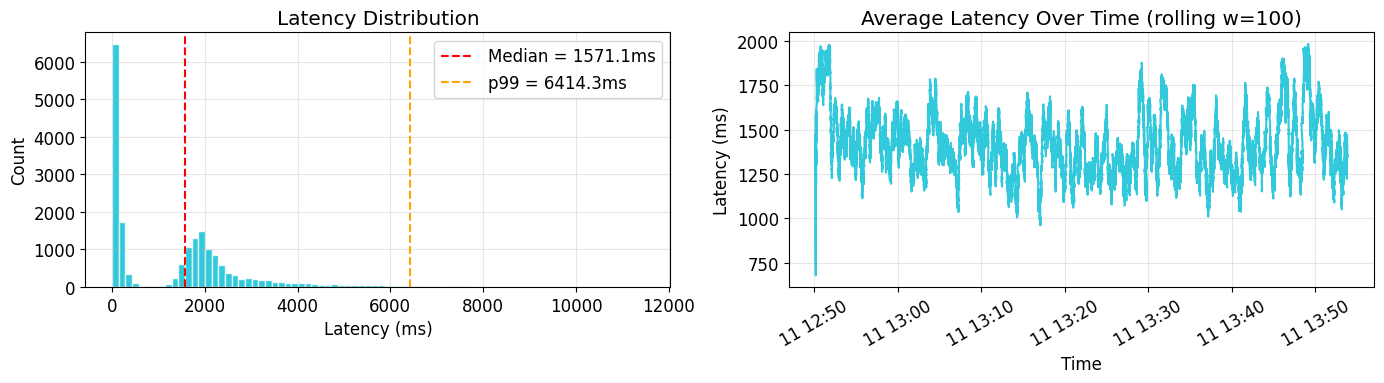

Latency: mean=1409.0ms, median=1571.1ms, p95=4184.5ms, p99=6414.3ms


In [38]:
latency_ms = requests['latency_seconds'] * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(latency_ms, bins=80, color='#00BCD4', edgecolor='white', alpha=0.8)
axes[0].axvline(latency_ms.median(), color='red', linestyle='--',
                label=f'Median = {latency_ms.median():.1f}ms')
axes[0].axvline(latency_ms.quantile(0.99), color='orange', linestyle='--',
                label=f'p99 = {latency_ms.quantile(0.99):.1f}ms')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('Latency Distribution')
axes[0].legend()

window = min(100, len(requests) // 5) if len(requests) > 10 else 1
axes[1].plot(requests['datetime'], latency_ms.rolling(window, min_periods=1).mean(),
             color='#00BCD4', alpha=0.8)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title(f'Average Latency Over Time (rolling w={window})')
plt.sca(axes[1])
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/latency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Latency: mean={latency_ms.mean():.1f}ms, median={latency_ms.median():.1f}ms, '
      f'p95={latency_ms.quantile(0.95):.1f}ms, p99={latency_ms.quantile(0.99):.1f}ms')

## Throughput and Execution Time (env.py Observables)

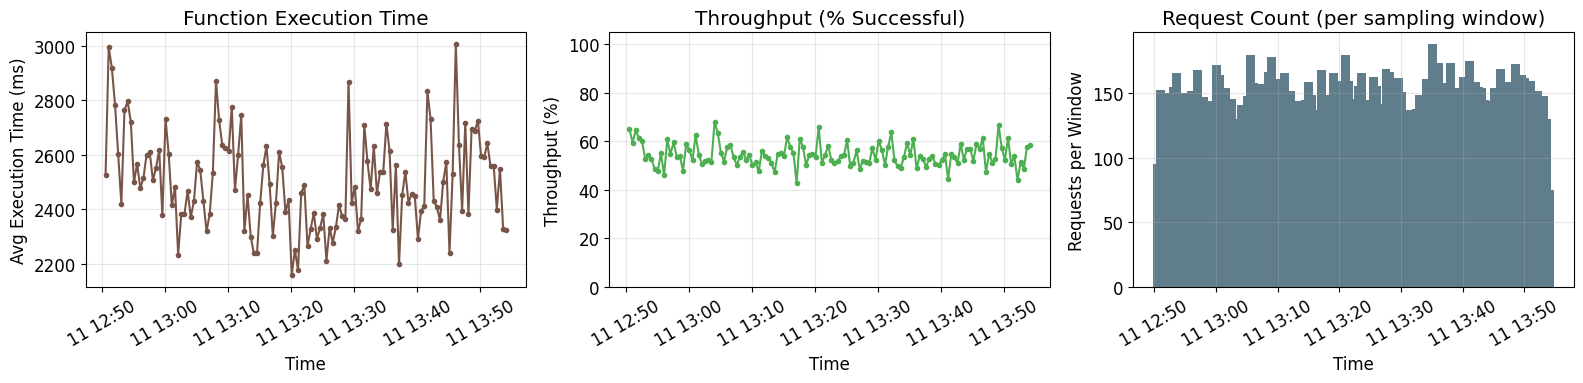

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(samples['datetime'], samples['avg_execution_time'] * 1000, color='#795548', marker='.')
axes[0].set_ylabel('Avg Execution Time (ms)')
axes[0].set_title('Function Execution Time')

axes[1].plot(samples['datetime'], samples['throughput'], color='#4CAF50', marker='.')
axes[1].set_ylabel('Throughput (%)')
axes[1].set_title('Throughput (% Successful)')
axes[1].set_ylim(0, 105)

axes[2].bar(samples['datetime'], samples['requests'], width=0.001, color='#607D8B')
axes[2].set_ylabel('Requests per Window')
axes[2].set_title('Request Count (per sampling window)')

for ax in axes:
    ax.set_xlabel('Time')
    plt.sca(ax)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/env_observables.png', dpi=150, bbox_inches='tight')
plt.show()

## CPU and Memory Utilization

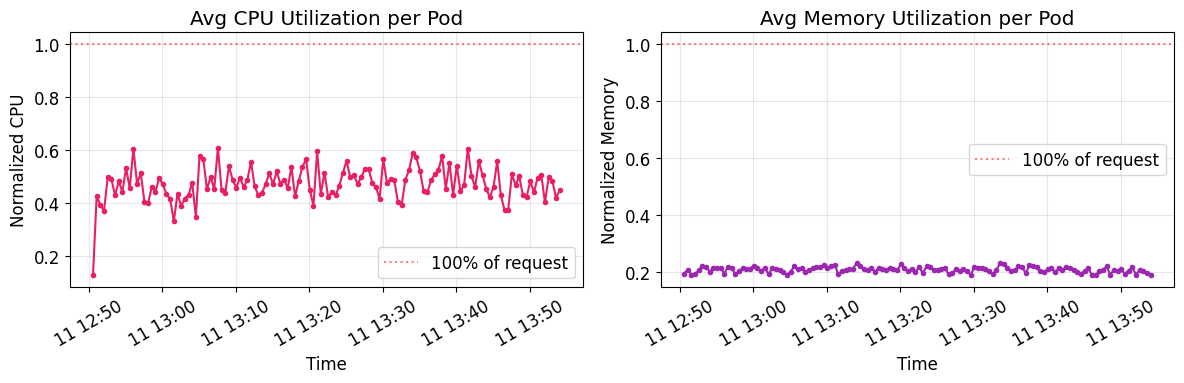

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(samples['datetime'], samples['avg_cpu'], color='#E91E63', marker='.')
axes[0].set_ylabel('Normalized CPU')
axes[0].set_title('Avg CPU Utilization per Pod')
axes[0].axhline(1.0, color='red', linestyle=':', alpha=0.5, label='100% of request')
axes[0].legend()

axes[1].plot(samples['datetime'], samples['avg_mem'], color='#9C27B0', marker='.')
axes[1].set_ylabel('Normalized Memory')
axes[1].set_title('Avg Memory Utilization per Pod')
axes[1].axhline(1.0, color='red', linestyle=':', alpha=0.5, label='100% of request')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Time')
    plt.sca(ax)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/cpu_mem.png', dpi=150, bbox_inches='tight')
plt.show()

## NSGD State Breakdown Over Time

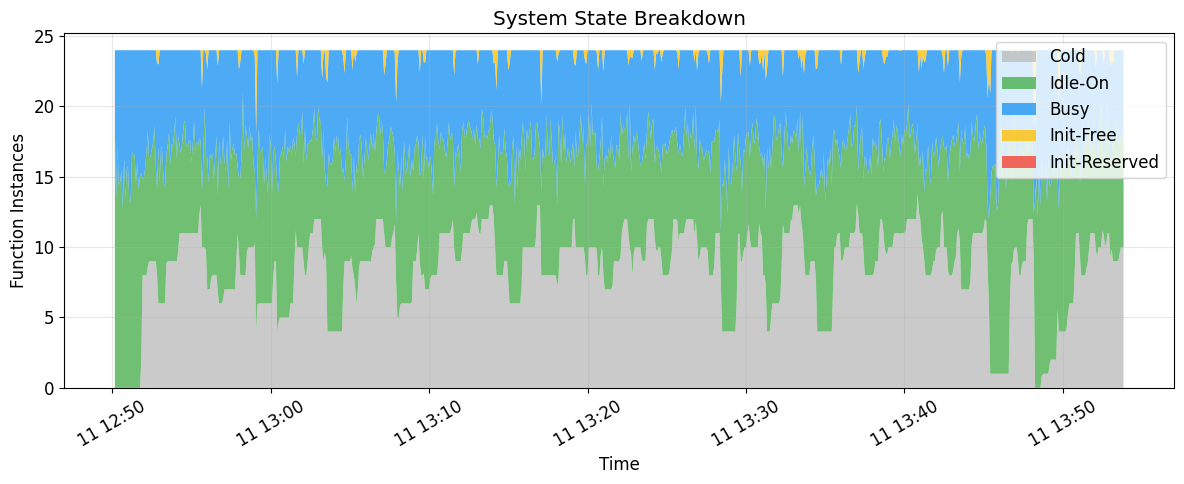

In [41]:
state_cols = ['cold', 'idle_on', 'busy', 'init_free', 'init_reserved']
resampled = requests.set_index('datetime')[state_cols].resample('5s').mean().dropna()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#BDBDBD', '#4CAF50', '#2196F3', '#FFC107', '#F44336']
ax.stackplot(
    resampled.index, *[resampled[c] for c in state_cols],
    labels=['Cold', 'Idle-On', 'Busy', 'Init-Free', 'Init-Reserved'],
    colors=colors, alpha=0.8,
)
ax.set_xlabel('Time')
ax.set_ylabel('Function Instances')
ax.set_title('System State Breakdown')
ax.legend(loc='upper right')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/state_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Plus vs Minus Phase Cost

In [ ]:
phase_cost = (
    training
    .dropna(subset=['iteration', 'phase'])
    .groupby(['iteration', 'phase'])['nsgd_cost']
    .mean()
    .unstack(fill_value=np.nan)
    .reset_index()
)

fig, ax = plt.subplots()
if 'plus' in phase_cost.columns:
    ax.plot(phase_cost['iteration'], phase_cost['plus'],
            marker='o', markersize=4, label='Plus phase', color='#4CAF50')
if 'minus' in phase_cost.columns:
    ax.plot(phase_cost['iteration'], phase_cost['minus'],
            marker='s', markersize=4, label='Minus phase', color='#F44336')
ax.set_xlabel('Iteration $n$')
ax.set_ylabel('Mean Cost')
ax.set_title('Cost: Plus vs Minus Perturbation Phases')
ax.legend()
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/phase_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## θ Step Values Applied (Perturbed)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['theta_stock', 'theta_idle', 'theta_exp'],
    [r'$\pi_{\theta_{stock}}$', r'$\pi_{\theta_{idle}}$', r'$\theta_{exp}$ (step)'],
    ['#2196F3', '#4CAF50', '#FF9800'],
):
    valid = training.dropna(subset=[col])
    ax.scatter(valid['datetime'], valid[col], s=2, alpha=0.3, color=color)
    ax.set_xlabel('Time')
    ax.set_ylabel(label)
    ax.set_title(label)
    plt.sca(ax)
    plt.xticks(rotation=30)

fig.suptitle('Applied θ (Perturbed) During Training', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/theta_step_applied.png', dpi=150, bbox_inches='tight')
plt.show()

## Periodic Samples — NSGD Cost

In [ ]:
fig, ax = plt.subplots()
ax.plot(samples['datetime'], samples['nsgd_cost'], marker='o', markersize=4, color='#E91E63')
ax.fill_between(samples['datetime'], 0, samples['nsgd_cost'], alpha=0.1, color='#E91E63')
ax.set_xlabel('Time')
ax.set_ylabel('NSGD Cost')
ax.set_title('NSGD Cost (Periodic Samples)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/periodic_cost.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Statistics Table

In [ ]:
def compute_stats(df, label):
    if len(df) == 0:
        return None
    return {
        'Phase': label,
        'Requests': len(df),
        'Mean Cost': round(df['nsgd_cost'].mean(), 2),
        'Std Cost': round(df['nsgd_cost'].std(), 2),
        'Cold Start %': round(df['is_cold_start'].mean() * 100, 2),
        'Rejection %': round(df['rejected'].mean() * 100, 2),
        'Mean Latency (ms)': round(df['latency_seconds'].mean() * 1000, 1),
        'p99 Latency (ms)': round(df['latency_seconds'].quantile(0.99) * 1000, 1),
        'Mean Replicas': round(df['ready_pods'].mean(), 1),
    }

# Per-request stats
rows = [s for s in [compute_stats(training, 'Training'),
                    compute_stats(evaluation, 'Evaluation')] if s]
request_stats = pd.DataFrame(rows).set_index('Phase')
print('=== Per-Request Statistics ===')
display(request_stats)

# Periodic sample stats (includes PPO reward)
print()
print('=== Periodic Sample Statistics ===')
periodic_stats = pd.DataFrame([{
    'Samples': len(samples),
    'Mean NSGD Cost': round(samples['nsgd_cost'].mean(), 2),
    'Std NSGD Cost': round(samples['nsgd_cost'].std(), 2),
    'Mean PPO Reward': round(samples['lstm_ppo_reward'].mean(), 2),
    'Std PPO Reward': round(samples['lstm_ppo_reward'].std(), 2),
    'Mean Throughput %': round(samples['throughput'].mean(), 1),
    'Mean Replicas': round(samples['replicas'].mean(), 1),
    'Mean CPU': round(samples['avg_cpu'].mean(), 3),
    'Mean Mem': round(samples['avg_mem'].mean(), 3),
}])
display(periodic_stats)

## Final θ Values

In [ ]:
last_training = training.dropna(subset=['theta_base_stock']).tail(1)

if len(last_training) > 0:
    row = last_training.iloc[0]
    print('Final learned θ (un-perturbed):')
    print(f'  θ_stock = {row["theta_base_stock"]:.4f}')
    print(f'  θ_idle  = {row["theta_base_idle"]:.4f}')
    print(f'  θ_exp   = {row["theta_base_exp"]:.4f}')
    print(f'  Iteration: {int(row["iteration"])}')
    print()
    if len(evaluation) > 0:
        print(f'Evaluation NSGD cost:  {evaluation["nsgd_cost"].mean():.2f} ± {evaluation["nsgd_cost"].std():.2f}')
        eval_samples = samples[samples['timestamp'] >= evaluation['timestamp'].min()]
        if len(eval_samples) > 0:
            print(f'Evaluation PPO reward: {eval_samples["lstm_ppo_reward"].mean():.2f} ± {eval_samples["lstm_ppo_reward"].std():.2f}')
    else:
        print('No evaluation data. Run: curl -X POST http://localhost:8000/mode/evaluate')
else:
    print('No training data with theta values found.')

## Saved Figures

In [ ]:
import glob
saved = sorted(glob.glob(f'{LOG_DIR}/*.png'))
print(f'Saved {len(saved)} figures to {LOG_DIR}/:')
for f in saved:
    print(f'  {f}')

In [7]:
# Find when evaluation mode started (from request_log)
eval_start = requests[requests['mode'] == 'evaluation']['timestamp'].min()

if pd.isna(eval_start):
    print("⚠ No evaluation data found. Run: curl -X POST http://localhost:8000/mode/evaluate")
    eval_samples = pd.DataFrame()
else:
    eval_samples = samples[samples['timestamp'] >= eval_start].copy()
    print(f"Evaluation period starts at: {pd.to_datetime(eval_start, unit='s')}")
    print(f"Evaluation samples: {len(eval_samples)}")

Evaluation period starts at: 2026-05-07 08:29:19.463171005
Evaluation samples: 356


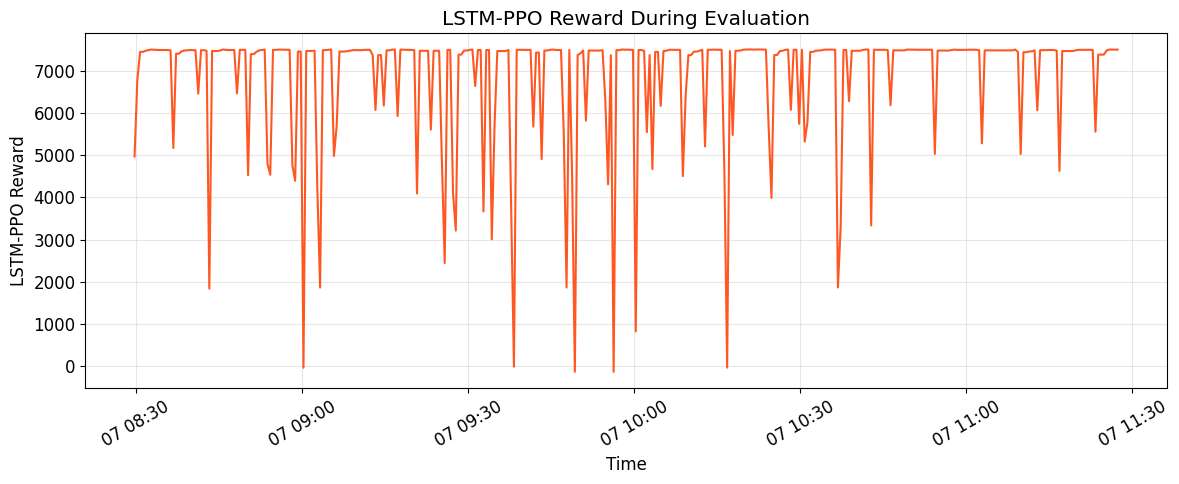

Mean: 6902.15
Min:  -129.82
Max:  7503.60


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eval_samples['datetime'], eval_samples['lstm_ppo_reward'],
        color='#FF5722')
ax.set_xlabel('Time')
ax.set_ylabel('LSTM-PPO Reward')
ax.set_title('LSTM-PPO Reward During Evaluation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/eval_lstm_ppo_reward.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean: {eval_samples["lstm_ppo_reward"].mean():.2f}')
print(f'Min:  {eval_samples["lstm_ppo_reward"].min():.2f}')
print(f'Max:  {eval_samples["lstm_ppo_reward"].max():.2f}')

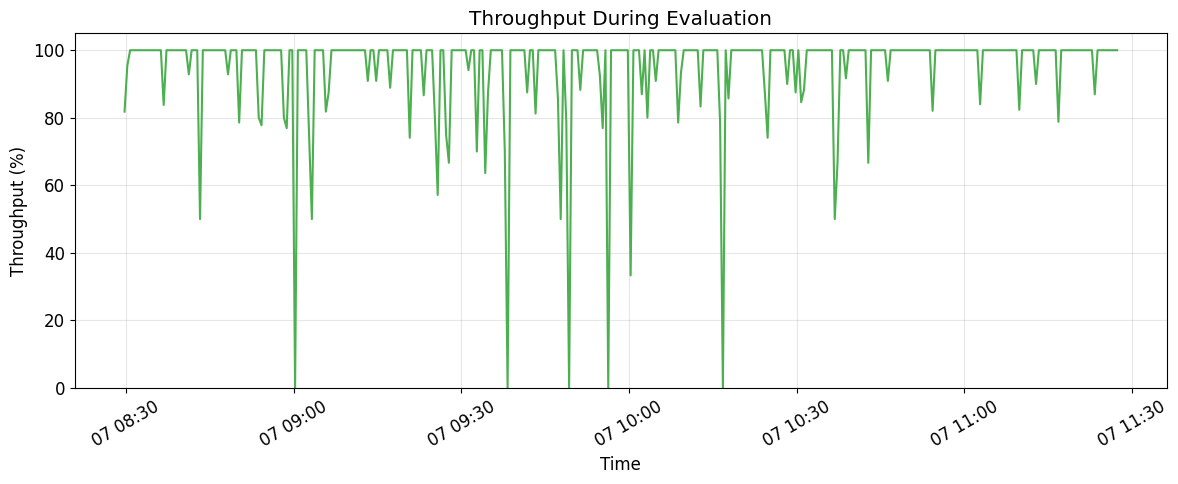

Mean: 94.98%
Min:  0.00%
Max:  100.00%


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eval_samples['datetime'], eval_samples['throughput'],
        color='#4CAF50')
ax.set_xlabel('Time')
ax.set_ylabel('Throughput (%)')
ax.set_title('Throughput During Evaluation')
ax.set_ylim(0, 105)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/eval_throughput.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean: {eval_samples["throughput"].mean():.2f}%')
print(f'Min:  {eval_samples["throughput"].min():.2f}%')
print(f'Max:  {eval_samples["throughput"].max():.2f}%')

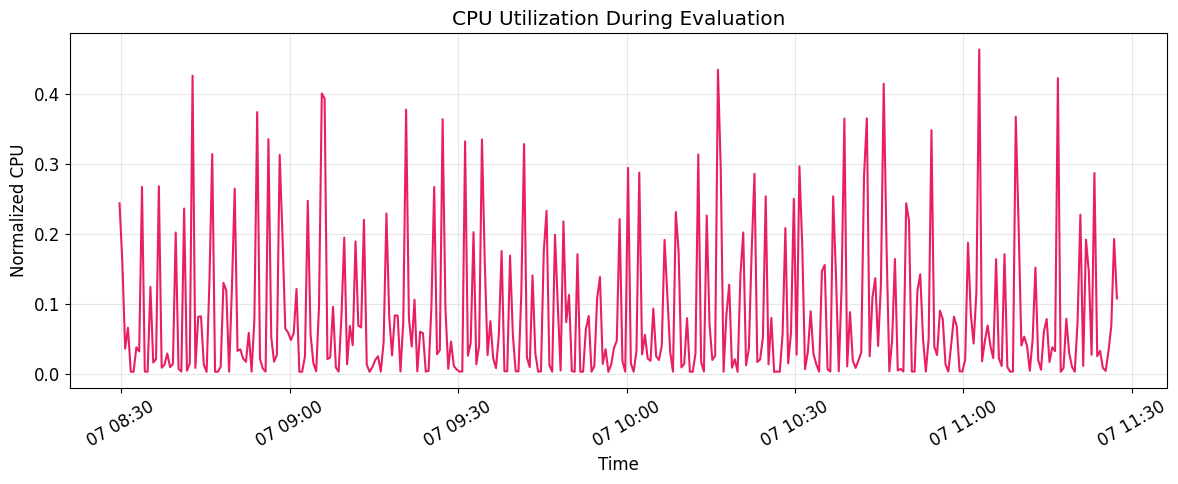

Mean: 0.0851
Min:  0.0025
Max:  0.4644


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eval_samples['datetime'], eval_samples['avg_cpu'],
        color='#E91E63')
ax.set_xlabel('Time')
ax.set_ylabel('Normalized CPU')
ax.set_title('CPU Utilization During Evaluation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/eval_cpu.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean: {eval_samples["avg_cpu"].mean():.4f}')
print(f'Min:  {eval_samples["avg_cpu"].min():.4f}')
print(f'Max:  {eval_samples["avg_cpu"].max():.4f}')

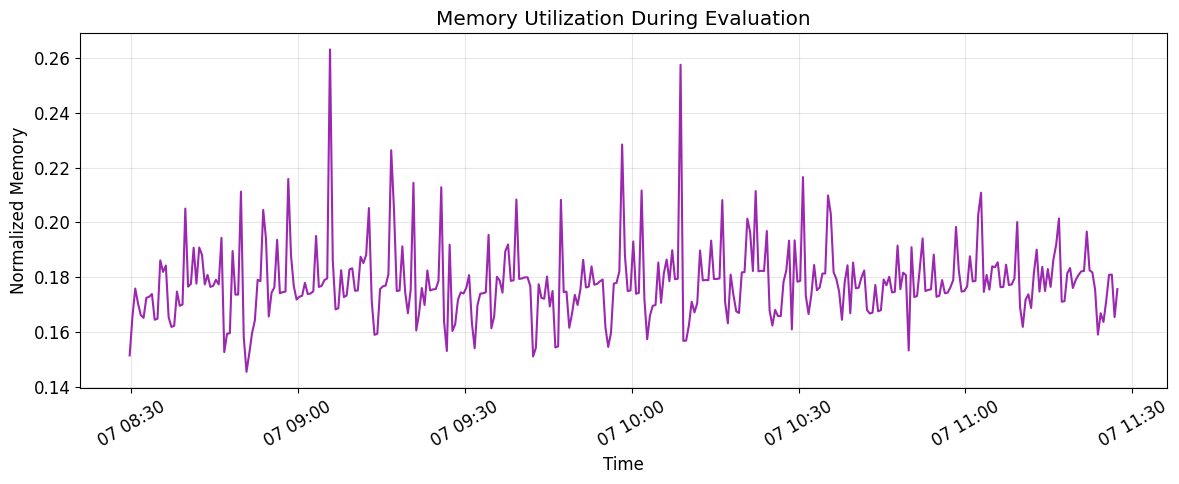

Mean: 0.1781
Min:  0.1454
Max:  0.2631


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eval_samples['datetime'], eval_samples['avg_mem'],
        color='#9C27B0')
ax.set_xlabel('Time')
ax.set_ylabel('Normalized Memory')
ax.set_title('Memory Utilization During Evaluation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/eval_memory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean: {eval_samples["avg_mem"].mean():.4f}')
print(f'Min:  {eval_samples["avg_mem"].min():.4f}')
print(f'Max:  {eval_samples["avg_mem"].max():.4f}')

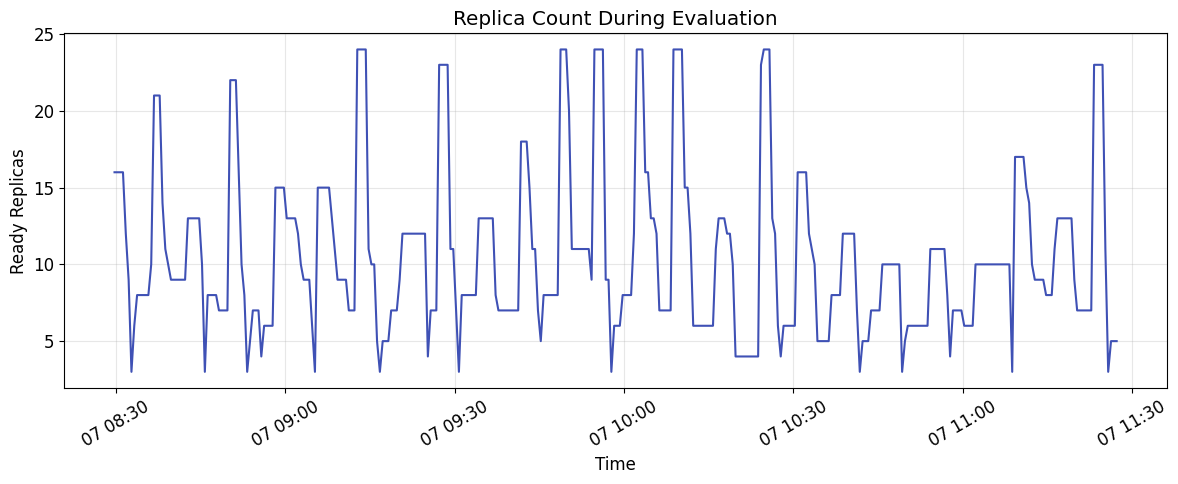

Mean: 10.62
Min:  3
Max:  24


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eval_samples['datetime'], eval_samples['replicas'],
        color='#3F51B5')
ax.set_xlabel('Time')
ax.set_ylabel('Ready Replicas')
ax.set_title('Replica Count During Evaluation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/eval_replicas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean: {eval_samples["replicas"].mean():.2f}')
print(f'Min:  {eval_samples["replicas"].min()}')
print(f'Max:  {eval_samples["replicas"].max()}')